# 🔬 Quantum Interference — The Engine of Quantum Algorithms

> *"Quantum computation is not parallelism — it is interference.*
> *The art of quantum algorithm design is the art of choreographing constructive and destructive*
> *interference of complex probability amplitudes."*

This notebook explores the **deepest physical principle** underlying every quantum speedup:
**interference of complex probability amplitudes**. We move beyond individual gates and
specific algorithms to reveal the **unifying mechanism** that powers quantum computation.

**What you will gain:**
- A rigorous mathematical understanding of quantum interference in Hilbert space
- The universal blueprint that every quantum algorithm follows
- Visual intuition for how phases encode information and interference extracts it
- Concrete implementations of Bernstein-Vazirani, Grover, Phase Estimation, and Simon — all through the interference lens
- Understanding of how entanglement and EPR pairs complete the algorithmic picture

## Your Intuition, Formalized

Your mental model is **correct in its essential structure**. Let us state it with full mathematical precision:

$$\boxed{|\psi_{\text{final}}\rangle \;=\; U_{\text{interfere}} \;\cdot\; U_{\text{oracle}} \;\cdot\; U_{\text{prepare}} \;|0\rangle^{\otimes n}}$$

1. **Prepare** ($U_{\text{prepare}}$): Create an equal superposition — launch the computation across all inputs simultaneously.
   Typically $H^{\otimes n}|0\rangle^{\otimes n} = \frac{1}{\sqrt{2^n}} \sum_{x=0}^{2^n - 1} |x\rangle$.

2. **Oracle** ($U_{\text{oracle}}$): Encode problem structure into the **phases** of the amplitudes.
   The oracle does not output a classical answer — it **imprints a phase pattern** onto the quantum state.
   Typically: $|x\rangle \mapsto (-1)^{f(x)}|x\rangle$ or $|x\rangle \mapsto e^{2\pi i \varphi(x)}|x\rangle$.

3. **Interfere** ($U_{\text{interfere}}$): Apply a transformation that causes amplitudes to add **constructively** for correct answers
   and **cancel destructively** for incorrect ones.

4. **Measure**: The interference pattern collapses to reveal the answer with high probability.

### A Crucial Refinement

The interference step is **not** merely "undoing the Hadamard." It is a **Fourier-type transform** that converts
**phase information** (invisible to measurement) into **amplitude information** (visible to measurement).
Depending on the algorithm, this transform takes different forms:

| Algorithm | Interference Transform | What It Reveals |
|---|---|---|
| Bernstein-Vazirani | $H^{\otimes n}$ | Hidden linear function |
| Simon | $H^{\otimes n}$ | Hidden period (subgroup structure) |
| Grover | $2|\psi\rangle\langle\psi| - I$ | Marked item via amplitude amplification |
| Shor / QPE | $\text{QFT}^{-1}$ | Eigenvalue phase / period of a function |

The physics is always the same: **constructive and destructive interference of complex amplitudes**.

---
### Setup & Imports

We use **Qiskit** with `BasicSimulator`, **NumPy** for linear algebra, and **Matplotlib** for
publication-quality visualizations of quantum states and interference patterns.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import random

from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_bloch_multivector

backend = BasicSimulator()
shots = 4096
seed = 42

# ── Visualization Helpers ──────────────────────────────────────────

def plot_state_phases(sv_data, n_qubits, title='', ax=None, show_phase_labels=True):
    """Bar chart of amplitude magnitudes, bars colored by complex phase."""
    n_states = len(sv_data)
    labels = [format(i, f'0{n_qubits}b') for i in range(n_states)]
    magnitudes = np.abs(sv_data)
    phases = np.angle(sv_data)
    norm = plt.Normalize(-np.pi, np.pi)
    cmap = plt.cm.hsv
    colors = [cmap(norm(p)) if m > 1e-10 else (0.85, 0.85, 0.85, 1.0)
              for p, m in zip(phases, magnitudes)]
    if ax is None:
        fig, ax = plt.subplots(figsize=(max(6, n_states * 0.7), 3.5))
    bars = ax.bar(labels, magnitudes, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Basis state |x\u27E9', fontsize=10)
    ax.set_ylabel('|\u03B1\u2093|', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ymax = max(magnitudes.max() * 1.35, 0.12)
    ax.set_ylim(0, ymax)
    if show_phase_labels:
        for bar, mag, ph in zip(bars, magnitudes, phases):
            if mag > 1e-10:
                ax.text(bar.get_x() + bar.get_width()/2, mag + ymax*0.02,
                        f'\u03C6={ph:+.2f}', ha='center', va='bottom', fontsize=7,
                        fontstyle='italic')
    ax.grid(axis='y', alpha=0.25)
    return ax

print('\u2705 Setup complete \u2014 backend:', type(backend).__name__)

✅ Setup complete — backend: BasicSimulator


---
## Part I — The Physics of Interference

### §1  Complex Amplitudes and the Interference Term

A quantum state in an $n$-qubit Hilbert space $\mathcal{H} = (\mathbb{C}^2)^{\otimes n}$ is:

$$|\psi\rangle = \sum_{x=0}^{N-1} \alpha_x |x\rangle, \qquad \alpha_x \in \mathbb{C}, \quad \sum_x |\alpha_x|^2 = 1$$

Each amplitude $\alpha_x = |\alpha_x|\, e^{i\varphi_x}$ carries a **magnitude** and a **phase**.
The Born rule gives measurement probabilities: $P(x) = |\alpha_x|^2$.

**Key insight**: measurement is *blind* to phase — $P(x)$ depends only on $|\alpha_x|$.
Yet **interference** is governed entirely by phase. This is the central tension in quantum computing.

### The Interference Term

When two computational paths contribute amplitudes $\alpha_1$ and $\alpha_2$ to the same outcome, the total probability is:

$$\boxed{P = |\alpha_1 + \alpha_2|^2 = |\alpha_1|^2 + |\alpha_2|^2 + \underbrace{2\,\text{Re}(\alpha_1^* \alpha_2)}_{\text{interference term}}}$$

This is **fundamentally different** from classical probability, where $P_{\text{classical}} = |\alpha_1|^2 + |\alpha_2|^2$.

- If $\alpha_1$ and $\alpha_2$ have the **same phase**: $2\,\text{Re}(\alpha_1^* \alpha_2) > 0$ → **constructive** interference → $P > P_{\text{classical}}$
- If $\alpha_1$ and $\alpha_2$ have **opposite phase**: $2\,\text{Re}(\alpha_1^* \alpha_2) < 0$ → **destructive** interference → $P < P_{\text{classical}}$
- If the phases are **orthogonal** (90°): $2\,\text{Re}(\alpha_1^* \alpha_2) = 0$ → no interference → $P = P_{\text{classical}}$

This is the **exact same physics** as the double-slit experiment, extended to $2^n$ computational paths.

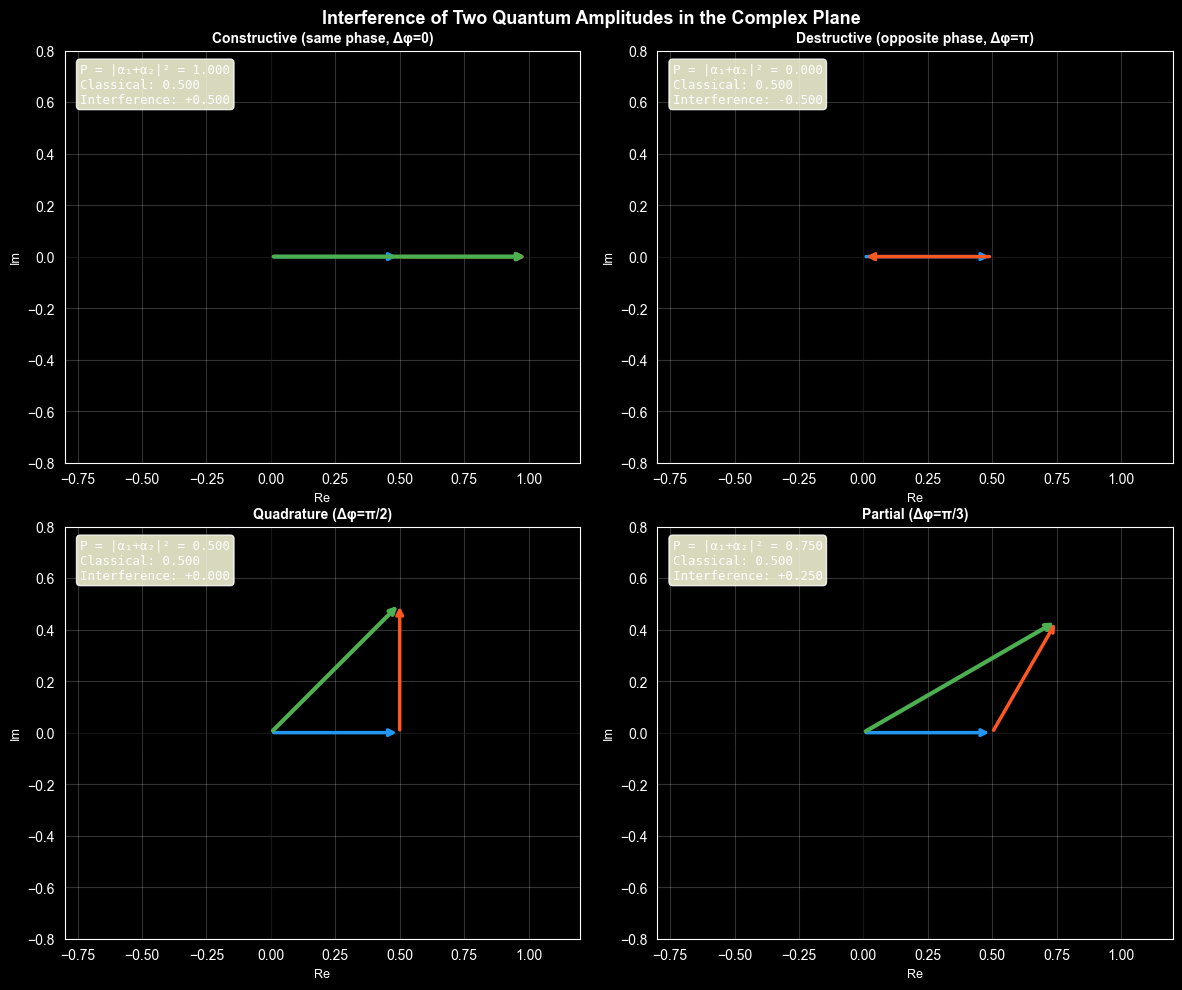

Blue = α₁, Orange = α₂, Green = α₁+α₂ (resultant)
The interference term 2·Re(α₁*α₂) is what separates quantum from classical.


In [2]:
# ═══ Phasor Interference: constructive vs destructive ═══════════════

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

cases = [
    (0.5+0j, 0.5+0j,               'Constructive (same phase, \u0394\u03C6=0)'),
    (0.5+0j, -0.5+0j,              'Destructive (opposite phase, \u0394\u03C6=\u03C0)'),
    (0.5+0j, 0.5j,                 'Quadrature (\u0394\u03C6=\u03C0/2)'),
    (0.5+0j, 0.5*np.exp(1j*np.pi/3), 'Partial (\u0394\u03C6=\u03C0/3)'),
]

for ax, (a1, a2, title) in zip(axes.flat, cases):
    total = a1 + a2
    # Draw phasor arrows
    ax.annotate('', xy=(a1.real, a1.imag), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#2196F3', lw=2.5))
    ax.annotate('', xy=(a1.real+a2.real, a1.imag+a2.imag),
                xytext=(a1.real, a1.imag),
                arrowprops=dict(arrowstyle='->', color='#FF5722', lw=2.5))
    if abs(total) > 1e-10:
        ax.annotate('', xy=(total.real, total.imag), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color='#4CAF50', lw=3))
    # Reference circle
    th = np.linspace(0, 2*np.pi, 100)
    ax.plot(np.cos(th)*0.5, np.sin(th)*0.5, 'k--', alpha=0.1, lw=0.8)
    # Style
    ax.set_xlim(-0.8, 1.2); ax.set_ylim(-0.8, 0.8)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Re', fontsize=9); ax.set_ylabel('Im', fontsize=9)
    # Probability annotation
    prob = abs(total)**2
    classical = abs(a1)**2 + abs(a2)**2
    interference = 2 * (a1.conjugate() * a2).real
    ax.text(0.03, 0.97,
            f'P = |\u03B1\u2081+\u03B1\u2082|\u00B2 = {prob:.3f}\n'
            f'Classical: {classical:.3f}\n'
            f'Interference: {interference:+.3f}',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85),
            family='monospace')

fig.suptitle('Interference of Two Quantum Amplitudes in the Complex Plane',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Blue = \u03B1\u2081, Orange = \u03B1\u2082, Green = \u03B1\u2081+\u03B1\u2082 (resultant)')
print('The interference term 2\u00B7Re(\u03B1\u2081*\u03B1\u2082) is what separates quantum from classical.')

### §2  Multi-Path Interference — The Source of Quantum Speedup

In a quantum algorithm, the amplitude of a target outcome $|y\rangle$ is a **sum over all $N = 2^n$ computational paths**:

$$\alpha_y = \frac{1}{N} \sum_{x=0}^{N-1} e^{i\varphi_x(y)}$$

where $\varphi_x(y)$ is the phase accumulated along path $x$ leading to outcome $y$.

**Two extreme cases reveal why quantum algorithms work:**

**Case 1 — Coherent phases** (correct answer): All $N$ phase terms align.
$$\alpha_y = \frac{1}{N} \cdot N \cdot e^{i\varphi_0} = e^{i\varphi_0} \quad\Rightarrow\quad P(y) = 1$$

**Case 2 — Random/incoherent phases** (wrong answer): The $N$ terms point in random directions and cancel.
$$|\alpha_y| \approx \frac{1}{N} \cdot \sqrt{N} = \frac{1}{\sqrt{N}} \quad\Rightarrow\quad P(y) \approx \frac{1}{N}$$

The ratio of probabilities is $P_{\text{correct}} / P_{\text{wrong}} \approx N$.
For $n = 20$ qubits, this is a factor of **over one million**.

This is the quantum advantage: an oracle-designed phase pattern causes $N$ paths to interfere
constructively at the correct answer and destructively everywhere else.

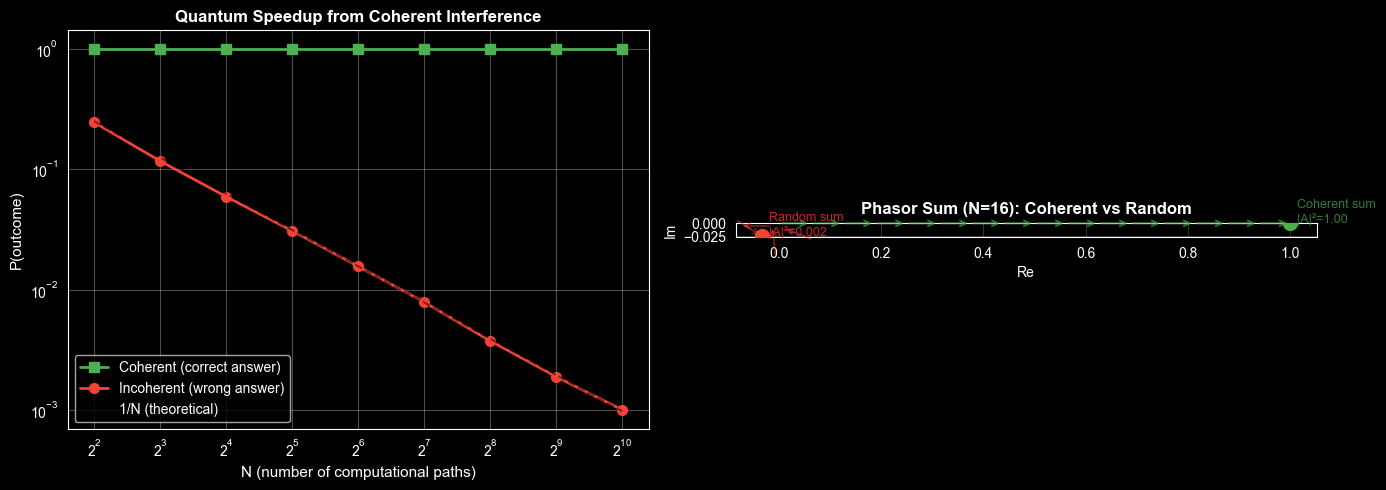

With N=1024 paths: P(coherent)=1.000, P(random)≈0.0010
Ratio: 999x — this IS the quantum speedup.


In [3]:
# ═══ Multi-path interference: coherent vs incoherent ═══════════════

np.random.seed(seed)
N_values = np.array([4, 8, 16, 32, 64, 128, 256, 512, 1024])
n_trials = 500

p_coherent = np.ones(len(N_values))  # always 1.0
p_incoherent_avg = np.zeros(len(N_values))

for idx, N in enumerate(N_values):
    probs = []
    for _ in range(n_trials):
        random_phases = np.random.uniform(0, 2*np.pi, N)
        phasors = np.exp(1j * random_phases) / N
        probs.append(abs(phasors.sum())**2)
    p_incoherent_avg[idx] = np.mean(probs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: probability vs N
ax1.plot(N_values, p_coherent, 's-', color='#4CAF50', lw=2, markersize=7,
         label='Coherent (correct answer)')
ax1.plot(N_values, p_incoherent_avg, 'o-', color='#F44336', lw=2, markersize=7,
         label='Incoherent (wrong answer)')
ax1.plot(N_values, 1.0/N_values, 'k--', alpha=0.5, label='1/N (theoretical)')
ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
ax1.set_xlabel('N (number of computational paths)', fontsize=11)
ax1.set_ylabel('P(outcome)', fontsize=11)
ax1.set_title('Quantum Speedup from Coherent Interference', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Right: phasor addition visualized for N=16
N_demo = 16
# Coherent case
ax2.set_title(f'Phasor Sum (N={N_demo}): Coherent vs Random', fontsize=12, fontweight='bold')
coherent_phasors = np.ones(N_demo) / N_demo + 0j
x_c, y_c = 0.0, 0.0
for p in coherent_phasors:
    ax2.annotate('', xy=(x_c + p.real, y_c + p.imag), xytext=(x_c, y_c),
                arrowprops=dict(arrowstyle='->', color='#4CAF50', lw=1.5, alpha=0.6))
    x_c += p.real; y_c += p.imag
ax2.plot(x_c, y_c, 'o', color='#4CAF50', markersize=10, zorder=5)
ax2.annotate(f'  Coherent sum\n  |A|\u00B2={abs(sum(coherent_phasors))**2:.2f}',
             xy=(x_c, y_c), fontsize=9, color='#2E7D32')

# Random case
np.random.seed(7)
random_phasors = np.exp(1j * np.random.uniform(0, 2*np.pi, N_demo)) / N_demo
x_r, y_r = 0.0, 0.0
for p in random_phasors:
    ax2.annotate('', xy=(x_r + p.real, y_r + p.imag), xytext=(x_r, y_r),
                arrowprops=dict(arrowstyle='->', color='#F44336', lw=1.2, alpha=0.5))
    x_r += p.real; y_r += p.imag
ax2.plot(x_r, y_r, 'o', color='#F44336', markersize=10, zorder=5)
ax2.annotate(f'  Random sum\n  |A|\u00B2={abs(sum(random_phasors))**2:.3f}',
             xy=(x_r, y_r), fontsize=9, color='#C62828')

ax2.set_aspect('equal')
ax2.grid(True, alpha=0.2)
ax2.axhline(0, color='k', lw=0.4); ax2.axvline(0, color='k', lw=0.4)
ax2.set_xlabel('Re', fontsize=10); ax2.set_ylabel('Im', fontsize=10)

plt.tight_layout()
plt.show()

print(f'With N=1024 paths: P(coherent)=1.000, P(random)\u2248{p_incoherent_avg[-1]:.4f}')
print(f'Ratio: {p_coherent[-1]/p_incoherent_avg[-1]:.0f}x \u2014 this IS the quantum speedup.')

---
## Part II — The Algorithm Blueprint

### §3  Phase Kickback: How Oracles Write in Phase

The mechanism by which oracles encode information into phases is **phase kickback**.
It is the single most important trick in quantum algorithms.

**The eigenvalue equation:**
If $U|u\rangle = e^{i\theta}|u\rangle$ (i.e., $|u\rangle$ is an eigenstate of $U$), then a controlled-$U$ gate acts as:

$$\text{C-}U\,|\psi\rangle|u\rangle = \left(\sum_x \alpha_x\, e^{i\theta \cdot x}|x\rangle\right)|u\rangle$$

The eigenvalue $e^{i\theta}$ is **kicked back** onto the control register.
The target $|u\rangle$ is unchanged — it acts as a **catalyst**.

**Common special case — the $|{-}\rangle$ trick:**

The state $|{-}\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}$ is an eigenstate of $X$ with eigenvalue $-1$.
Using a CNOT (controlled-$X$) with target in $|{-}\rangle$:

$$\text{CNOT}\,|x\rangle|{-}\rangle = (-1)^x|x\rangle|{-}\rangle$$

More generally, for any Boolean function $f$ implemented as $U_f|x\rangle|y\rangle = |x\rangle|y \oplus f(x)\rangle$:

$$U_f|x\rangle|{-}\rangle = (-1)^{f(x)}|x\rangle|{-}\rangle$$

This transforms a **bit-flip oracle** into a **phase oracle** — the function value $f(x)$ becomes a phase $(-1)^{f(x)}$.
The ancilla $|{-}\rangle$ is never measured and can be discarded.

C:\Users\bmilanovic\AppData\Local\Temp\ipykernel_11800\1976507050.py:26: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Arial.
  plt.tight_layout()
C:\Dev\azure\quantum-notebook\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


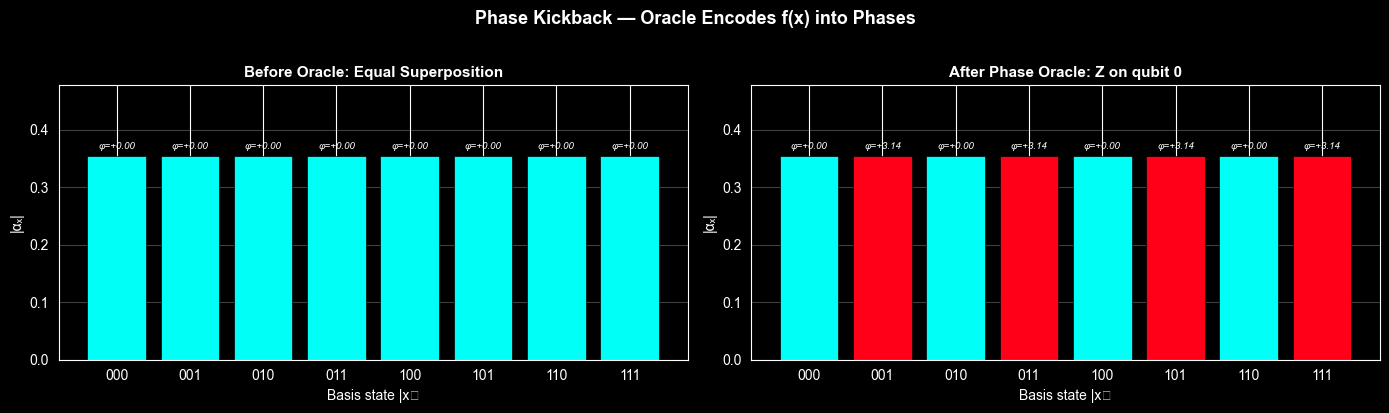

Before oracle: all amplitudes have phase φ=0
After oracle:  states with qubit 0 = |1⟩ get phase φ=π (sign flip)
The oracle wrote f(x) = x₀ into the PHASES — magnitudes unchanged!
✅ Assertion passed: |α_x| identical before and after oracle


In [4]:
# ═══ Phase Kickback Demonstration ═════════════════════════════════
# Show how a CNOT with target in |-⟩ creates a phase oracle.

n_qubits = 3
N = 2**n_qubits

# Step 1: Create equal superposition on input register
qc1 = QuantumCircuit(n_qubits)
for i in range(n_qubits):
    qc1.h(i)
sv_before = np.array(Statevector.from_instruction(qc1))

# Step 2: Apply phase oracle for f(x) = x_0 (parity of bit 0)
# Phase oracle: Z gate on qubit 0 gives (-1)^{x_0}
qc2 = QuantumCircuit(n_qubits)
for i in range(n_qubits):
    qc2.h(i)
qc2.z(0)  # Phase kickback: flips sign when qubit 0 is |1\u27E9
sv_after = np.array(Statevector.from_instruction(qc2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
plot_state_phases(sv_before, n_qubits, 'Before Oracle: Equal Superposition', ax=ax1)
plot_state_phases(sv_after, n_qubits, 'After Phase Oracle: Z on qubit 0', ax=ax2)
fig.suptitle('Phase Kickback \u2014 Oracle Encodes f(x) into Phases',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Before oracle: all amplitudes have phase \u03C6=0')
print('After oracle:  states with qubit 0 = |1\u27E9 get phase \u03C6=\u03C0 (sign flip)')
print('The oracle wrote f(x) = x\u2080 into the PHASES \u2014 magnitudes unchanged!')

# Verify magnitudes unchanged
assert np.allclose(np.abs(sv_before), np.abs(sv_after)), 'Magnitudes must be unchanged'
print('\u2705 Assertion passed: |\u03B1_x| identical before and after oracle')

---
## Part III — Algorithms as Interference Machines

### §4  Bernstein-Vazirani: One-Shot Interference

**Problem:** Given a black-box oracle for $f(x) = s \cdot x \pmod{2}$ where $s$ is a secret $n$-bit string,
find $s$ using as few queries as possible.

**Classical:** requires $n$ queries (one per bit). **Quantum: one query.**

**The interference mechanism:**

1. **Prepare:** $|0\rangle^{\otimes n} \xrightarrow{H^{\otimes n}} \frac{1}{\sqrt{N}} \sum_x |x\rangle$

2. **Oracle (phase):** $\frac{1}{\sqrt{N}} \sum_x |x\rangle \xrightarrow{O_f} \frac{1}{\sqrt{N}} \sum_x (-1)^{s \cdot x} |x\rangle$

3. **Interfere:** $H^{\otimes n}$ maps this to:
$$\alpha_y = \frac{1}{N} \sum_{x=0}^{N-1} (-1)^{s \cdot x + x \cdot y} = \frac{1}{N} \sum_{x=0}^{N-1} (-1)^{(s \oplus y) \cdot x}$$

4. **Key identity:** $\frac{1}{N}\sum_x (-1)^{z \cdot x} = \delta_{z, 0}$ (equals 1 if $z = 0$, else 0).

Therefore: $\alpha_y = \delta_{y, s}$, i.e., the amplitude is **1 at $|s\rangle$** and **0 everywhere else**.

All $N$ paths interfere **perfectly constructively** at $|s\rangle$ and **perfectly destructively** at every other state.
One measurement reveals $s$ with certainty.

**Implementation below:** $n = 4$, secret $s = 1011$ (decimal 11). The phase oracle applies $Z$ to each qubit $j$ where $s_j = 1$.

C:\Users\bmilanovic\AppData\Local\Temp\ipykernel_11800\1689413524.py:35: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\bmilanovic\AppData\Local\Temp\ipykernel_11800\1689413524.py:35: UserWarning: Glyph 8855 (\N{CIRCLED TIMES}) missing from font(s) Arial.
  plt.tight_layout()
C:\Dev\azure\quantum-notebook\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8855 (\N{CIRCLED TIMES}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


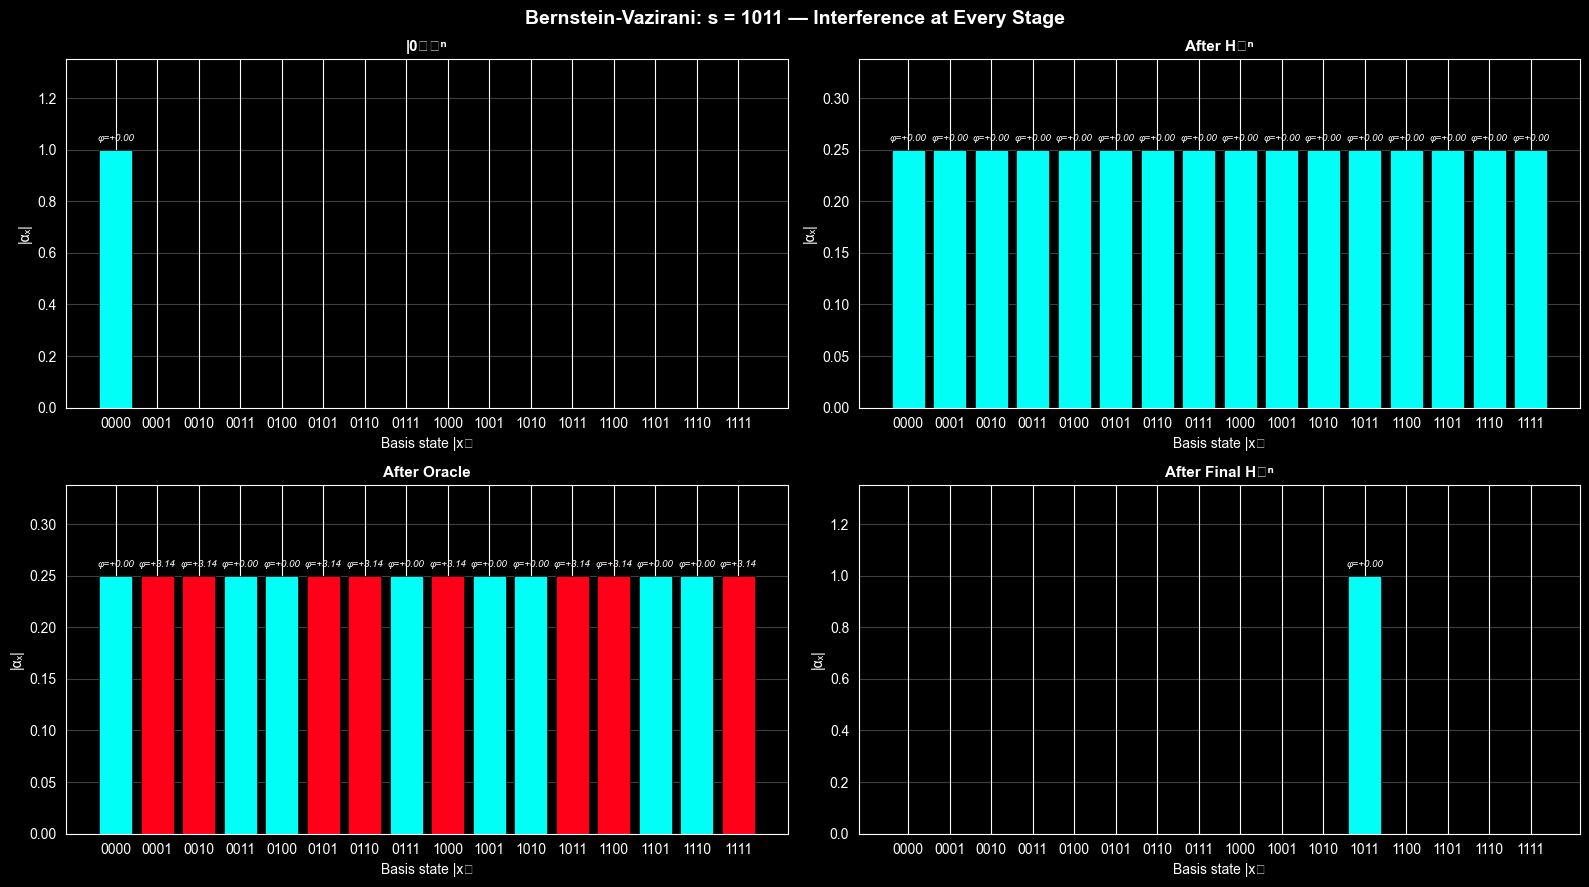

Secret string s = 1011
Measurement result: {'1011': 4096}
✅ All 4096 measurements returned |1011⟩ — perfect constructive interference!


In [5]:
# ═══ Bernstein-Vazirani: complete interference analysis ═══════════

n = 4
secret = '1011'
N_bv = 2**n

# Track state at each stage
stages = {}

# Stage 0: initial
qc = QuantumCircuit(n)
stages['|0\u27E9\u2297\u207F'] = np.array(Statevector.from_instruction(qc))

# Stage 1: after H
qc.h(range(n))
stages['After H\u2297\u207F'] = np.array(Statevector.from_instruction(qc))

# Stage 2: phase oracle - apply Z where secret bit is 1
# In Qiskit little-endian: qubit j corresponds to bit j (LSB)
for j in range(n):
    if secret[n - 1 - j] == '1':  # Map string index to qubit index
        qc.z(j)
stages['After Oracle'] = np.array(Statevector.from_instruction(qc))

# Stage 3: final H (interference)
qc.h(range(n))
stages['After Final H\u2297\u207F'] = np.array(Statevector.from_instruction(qc))

# Visualize all four stages
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
for ax, (label, sv) in zip(axes.flat, stages.items()):
    plot_state_phases(sv, n, label, ax=ax)
fig.suptitle(f'Bernstein-Vazirani: s = {secret} \u2014 Interference at Every Stage',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Verify: measure should give secret string with certainty
qc_m = qc.copy()
qc_m.measure_all()
compiled = transpile(qc_m, backend, seed_transpiler=seed)
counts = backend.run(compiled, shots=shots, seed_simulator=seed).result().get_counts()
print(f'Secret string s = {secret}')
print(f'Measurement result: {counts}')
assert secret in counts and counts[secret] == shots
print(f'\u2705 All {shots} measurements returned |{secret}\u27E9 \u2014 perfect constructive interference!')

### §5  Grover's Search: Geometric Amplitude Amplification

**Problem:** Given an oracle that marks a single item $|w\rangle$ among $N$ items, find $w$.

**Classical:** $O(N)$ queries.  **Quantum:** $O(\sqrt{N})$ queries.

Grover's algorithm uses a fundamentally different interference mechanism: **amplitude amplification**
through repeated reflection.

**The geometry:** The entire computation lives in a 2D plane spanned by:
- $|w\rangle$: the marked state
- $|w^\perp\rangle = \frac{1}{\sqrt{N-1}}\sum_{x \neq w} |x\rangle$: the uniform superposition of all *unmarked* states

The initial state is:
$$|\psi\rangle = \sin\theta\,|w\rangle + \cos\theta\,|w^\perp\rangle, \qquad \sin\theta = \frac{1}{\sqrt{N}}$$

Each **Grover iteration** consists of:
1. **Oracle** $O$: Reflect about $|w^\perp\rangle$ — flip the sign of $|w\rangle$
2. **Diffusion** $D = 2|\psi\rangle\langle\psi| - I$: Reflect about $|\psi\rangle$ — "inversion about the mean"

The composition $G = D \cdot O$ is a **rotation by $2\theta$** in the 2D plane:

$$G^k|\psi\rangle = \sin\big((2k+1)\theta\big)|w\rangle + \cos\big((2k+1)\theta\big)|w^\perp\rangle$$

After $k \approx \frac{\pi}{4}\sqrt{N}$ iterations, $(2k+1)\theta \approx \frac{\pi}{2}$, and the state
is almost entirely $|w\rangle$.

**The interference picture:** The diffusion operator computes the mean amplitude and reflects each amplitude about it.
The marked state (with negative amplitude after the oracle) gets boosted, while unmarked states get suppressed.
This is interference: the mean acts as a reference, and each amplitude interferes with this collective average.

C:\Users\bmilanovic\AppData\Local\Temp\ipykernel_11800\2473540682.py:63: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\bmilanovic\AppData\Local\Temp\ipykernel_11800\2473540682.py:63: UserWarning: Glyph 8855 (\N{CIRCLED TIMES}) missing from font(s) Arial.
  plt.tight_layout()


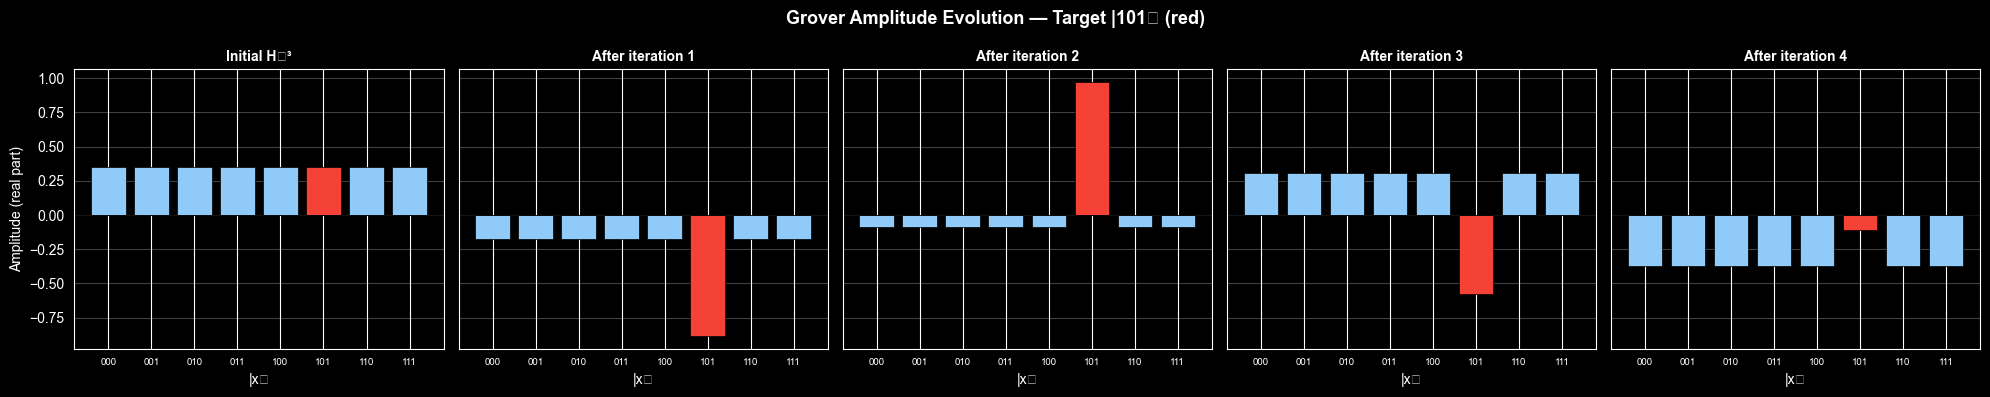

Target: |101⟩, N=8, optimal iterations=2
P(target) theory = sin²(5θ) = 0.9453
P(target) sim    = 0.9453
✅ Theory matches simulation. Interference amplified |101⟩!


In [6]:
# ═══ Grover's Search: amplitude evolution visualization ═══════════

n_grover = 3
N_grover = 2**n_grover
target = 5  # |101\u27E9

def grover_oracle(qc, target_state, n):
    """Phase-flip the target state."""
    bits = format(target_state, f'0{n}b')[::-1]  # Reversed for Qiskit
    for i, b in enumerate(bits):
        if b == '0':
            qc.x(i)
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)
    for i, b in enumerate(bits):
        if b == '0':
            qc.x(i)

def grover_diffusion(qc, n):
    """Inversion about the mean (diffusion operator)."""
    qc.h(range(n))
    qc.x(range(n))
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)
    qc.x(range(n))
    qc.h(range(n))

# Track amplitudes through iterations
n_iters = 4
amp_history = []

qc = QuantumCircuit(n_grover)
qc.h(range(n_grover))
sv = np.array(Statevector.from_instruction(qc))
amp_history.append(('Initial H\u2297\u00B3', sv.real.copy()))

for it in range(n_iters):
    grover_oracle(qc, target, n_grover)
    grover_diffusion(qc, n_grover)
    sv = np.array(Statevector.from_instruction(qc))
    amp_history.append((f'After iteration {it+1}', sv.real.copy()))

# Plot amplitude evolution
fig, axes = plt.subplots(1, len(amp_history), figsize=(4*len(amp_history), 4),
                         sharey=True)
labels = [format(i, f'0{n_grover}b') for i in range(N_grover)]
target_label = format(target, f'0{n_grover}b')

for ax, (title, amps) in zip(axes, amp_history):
    colors = ['#F44336' if i == target else '#90CAF9' for i in range(N_grover)]
    ax.bar(labels, amps, color=colors, edgecolor='black', linewidth=0.5)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('|x\u27E9')
    ax.tick_params(axis='x', labelsize=7)
    ax.grid(axis='y', alpha=0.25)

axes[0].set_ylabel('Amplitude (real part)')
fig.suptitle(f'Grover Amplitude Evolution \u2014 Target |{target_label}\u27E9 (red)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Probability of target after optimal iterations (k=2 for N=8)
optimal_k = 2
theta = np.arcsin(1 / np.sqrt(N_grover))
p_theory = np.sin((2*optimal_k + 1) * theta)**2
p_sim = abs(amp_history[optimal_k][1][target])**2
print(f'Target: |{target_label}\u27E9, N={N_grover}, optimal iterations={optimal_k}')
print(f'P(target) theory = sin\u00B2({2*optimal_k+1}\u03B8) = {p_theory:.4f}')
print(f'P(target) sim    = {p_sim:.4f}')
assert abs(p_theory - p_sim) < 1e-6
print(f'\u2705 Theory matches simulation. Interference amplified |{target_label}\u27E9!')

### §6  Quantum Phase Estimation: Fourier Interference

**Problem:** Given a unitary $U$ and an eigenstate $|u\rangle$ with $U|u\rangle = e^{2\pi i \varphi}|u\rangle$,
estimate the phase $\varphi$ to $t$ bits of precision.

QPE is the backbone of **Shor's algorithm** (for factoring) and many quantum simulation algorithms.

**The mechanism** uses a different flavor of interference — the **Quantum Fourier Transform (QFT)**.

**Step 1 — Controlled powers:** Apply controlled-$U^{2^k}$ from counting qubit $k$ to the target:
$$|0\rangle + e^{2\pi i \cdot 2^k \varphi}|1\rangle \quad \text{on qubit } k$$

After all $t$ counting qubits:
$$|\psi\rangle = \frac{1}{\sqrt{2^t}}\bigotimes_{k=0}^{t-1}\left(|0\rangle + e^{2\pi i \cdot 2^k \varphi}|1\rangle\right)$$

This is exactly the **QFT of $|\tilde{\varphi}\rangle$** where $\tilde{\varphi}$ is the $t$-bit binary representation of $\varphi$.

**Step 2 — Inverse QFT:** $\text{QFT}^{-1}|\psi\rangle = |\tilde{\varphi}\rangle$.

The inverse QFT creates interference among the $2^t$ terms. At the correct binary representation of $\varphi$,
all terms constructively interfere. At incorrect values, they destructively cancel.

**Implementation below:** $U = T$ gate ($\varphi = 1/8$), $t = 3$ counting qubits. Expected result: $|001\rangle$ (binary $1 = 8 \times 1/8$).

C:\Users\bmilanovic\AppData\Local\Temp\ipykernel_11800\2751293359.py:54: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Arial.
  plt.tight_layout()


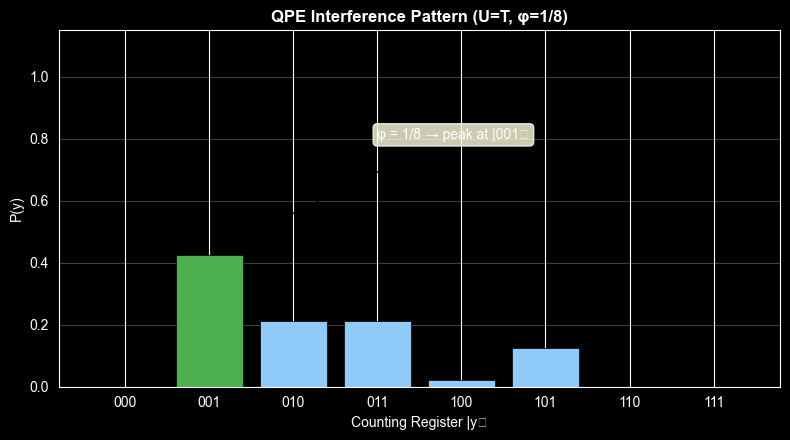

QPE Circuit:
     ┌───┐                                                                    »
q_0: ┤ H ├─■────────────────────────X──────────────────────■─────────■────────»
     ├───┤ │                        │                ┌───┐ │         │P(-π/2) »
q_1: ┤ H ├─┼────────■───────────────┼───────■────────┤ H ├─┼─────────■────────»
     ├───┤ │        │               │ ┌───┐ │P(-π/2) └───┘ │P(-π/4)           »
q_2: ┤ H ├─┼────────┼────────■──────X─┤ H ├─■──────────────■──────────────────»
     ├───┤ │P(π/4)  │P(π/2)  │P(π)    └───┘                                   »
q_3: ┤ X ├─■────────■────────■────────────────────────────────────────────────»
     └───┘                                                                    »
«     ┌───┐
«q_0: ┤ H ├
«     └───┘
«q_1: ─────
«          
«q_2: ─────
«          
«q_3: ─────
«          
U = T gate, eigenvalue = exp(2πi · 1/8)
Expected: |001⟩ (binary 1 = 8 × 1/8)
Measured: {'101': 488, '001': 1746, '011': 881, '010': 908, '100': 73}
Estimated φ

In [7]:
# ═══ Quantum Phase Estimation for U = T gate (\u03C6 = 1/8) ═══════════

t = 3  # counting qubits
n_target = 1
total_qubits = t + n_target

qc_qpe = QuantumCircuit(total_qubits)  # No classical bits for statevector

# Prepare target eigenstate |1\u27E9
qc_qpe.x(t)

# Hadamard on counting qubits
qc_qpe.h(range(t))

# Controlled-U^{2^k}: T^{2^k} has phase 2^k * \u03C0/4
for k in range(t):
    angle = 2**k * np.pi / 4
    qc_qpe.cp(angle, k, t)

# Inverse QFT on counting qubits [0, 1, 2]
# Swap for bit reversal
qc_qpe.swap(0, 2)
# Apply inverse QFT gates (descending order)
for j in range(t - 1, -1, -1):
    for k in range(t - 1, j, -1):
        qc_qpe.cp(-np.pi / 2**(k - j), k, j)
    qc_qpe.h(j)

# Statevector analysis
sv_qpe = np.array(Statevector.from_instruction(qc_qpe))

# Extract counting register probabilities (trace out target qubit)
probs_counting = np.zeros(2**t)
for i in range(2**total_qubits):
    counting_bits = i % (2**t)
    probs_counting[counting_bits] += abs(sv_qpe[i])**2

# Visualize the interference pattern
fig, ax1 = plt.subplots(figsize=(8, 4.5))

labels_qpe = [format(i, f'0{t}b') for i in range(2**t)]
colors_qpe = ['#4CAF50' if i == 1 else '#90CAF9' for i in range(2**t)]
ax1.bar(labels_qpe, probs_counting, color=colors_qpe, edgecolor='black', lw=0.5)
ax1.set_xlabel('Counting Register |y\u27E9', fontsize=10)
ax1.set_ylabel('P(y)', fontsize=10)
ax1.set_title('QPE Interference Pattern (U=T, \u03C6=1/8)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 1.15)
ax1.grid(axis='y', alpha=0.25)
ax1.annotate(f'\u03C6 = 1/8 \u2192 peak at |001\u27E9', xy=(1, probs_counting[1]),
             xytext=(3, 0.8), fontsize=10,
             arrowprops=dict(arrowstyle='->', color='black'),
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

# Show circuit
print('QPE Circuit:')
print(qc_qpe.draw(output='text'))

# Measure
qc_qpe_m = QuantumCircuit(total_qubits, t)
qc_qpe_m.compose(qc_qpe, inplace=True)
qc_qpe_m.measure(range(t), range(t))
compiled = transpile(qc_qpe_m, backend, seed_transpiler=seed)
counts_qpe = backend.run(compiled, shots=shots, seed_simulator=seed).result().get_counts()

print(f'U = T gate, eigenvalue = exp(2\u03C0i \u00B7 1/8)')
print(f'Expected: |001\u27E9 (binary 1 = 8 \u00D7 1/8)')
print(f'Measured: {counts_qpe}')
measured_phase = int(max(counts_qpe, key=counts_qpe.get), 2) / 2**t
print(f'Estimated \u03C6 = {measured_phase} (exact: 0.125)')
assert abs(measured_phase - 0.125) < 1e-9
print('\u2705 QPE correctly identified the phase through Fourier interference!')

### §7  Simon's Algorithm: Interference Reveals Hidden Structure

**Problem:** Given a 2-to-1 function $f$ with the promise that $f(x) = f(x \oplus s)$ for a hidden string $s \neq 0$,
find $s$.

**Classical:** requires $O(2^{n/2})$ queries. **Quantum:** $O(n)$ queries.

**The interference mechanism:**

1. Prepare superposition and apply oracle: the state becomes
$$\frac{1}{\sqrt{2^n}} \sum_x |x\rangle|f(x)\rangle$$

2. After the oracle, pairs $(x, x \oplus s)$ map to the same $f$-value. The input register is:
$$\frac{1}{\sqrt{2}}\big(|x\rangle + |x \oplus s\rangle\big)$$
   for some random $x$ (determined by which $f$-value was "selected" by entanglement).

3. Apply $H^{\otimes n}$ to the input register. The amplitude for measuring $|y\rangle$ is:
$$\alpha_y \propto (-1)^{x \cdot y} + (-1)^{(x \oplus s) \cdot y} = (-1)^{x \cdot y}\big(1 + (-1)^{s \cdot y}\big)$$

4. This is **non-zero only when** $s \cdot y = 0 \pmod{2}$.
   When $s \cdot y = 0$: the two terms add constructively: $\alpha_y \propto 2(-1)^{x \cdot y}$.
   When $s \cdot y = 1$: the two terms cancel perfectly: $\alpha_y = 0$ (destructive interference).

Each measurement gives a random $y$ orthogonal to $s$. After $O(n)$ measurements, we can solve the
linear system to find $s$.

**Implementation:** $n = 2$, $s = 11$, $f(x) = f(x \oplus 11)$.

C:\Users\bmilanovic\AppData\Local\Temp\ipykernel_11800\3193181551.py:63: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Arial.
  plt.tight_layout()


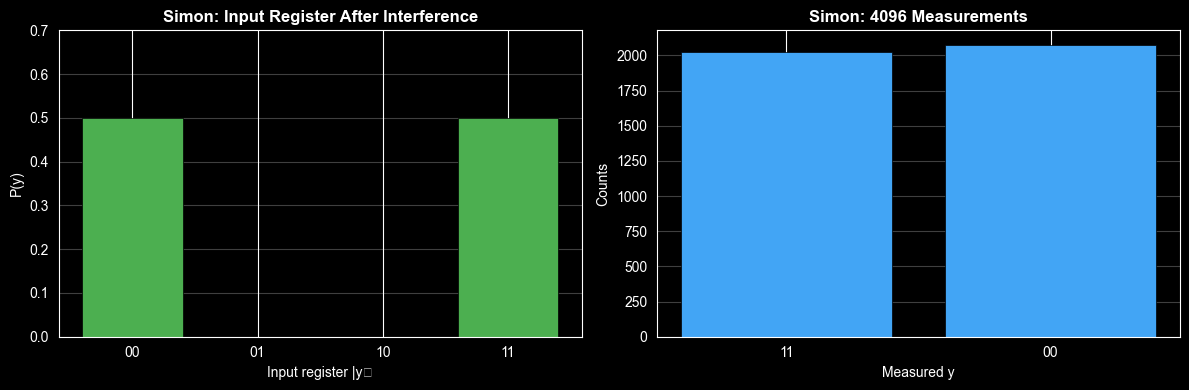

Hidden string s = 11
Measured outcomes: {'11': 2022, '00': 2074}
  y=11: y·s = 0 ✅
  y=00: y·s = 0 ✅
Only y with y·s=0 survive — destructive interference killed the rest!


In [8]:
# ═══ Simon's Algorithm: n=2, hidden string s="11" ═══════════════════

n_simon = 2
s_simon = '11'

# Oracle for f(00)=00, f(01)=01, f(10)=01, f(11)=00
# f(x) = f(x \u2295 11): verified by f(00)=f(11)=00, f(01)=f(10)=01
# Implementation: out_0 = x_0 \u2295 x_1 (CNOT x0->out0, CNOT x1->out0)

qc_simon = QuantumCircuit(2 * n_simon, n_simon)  # 4 qubits, 2 classical bits

# Step 1: Hadamard on input register (qubits 0, 1)
qc_simon.h([0, 1])
qc_simon.barrier()

# Step 2: Oracle
qc_simon.cx(0, 2)  # CNOT x_0 -> out_0
qc_simon.cx(1, 2)  # CNOT x_1 -> out_0 (so out_0 = x_0 XOR x_1)
qc_simon.barrier()

# Step 3: Hadamard on input register
qc_simon.h([0, 1])

# Step 4: Measure input register only
qc_simon.measure([0, 1], [0, 1])

# Exact statevector before measurement (without measure gates)
qc_simon_sv = QuantumCircuit(2 * n_simon)
qc_simon_sv.h([0, 1])
qc_simon_sv.cx(0, 2)
qc_simon_sv.cx(1, 2)
qc_simon_sv.h([0, 1])
sv_simon = np.array(Statevector.from_instruction(qc_simon_sv))

# Trace out output register to get input register probabilities
probs_input = np.zeros(2**n_simon)
for i in range(2**(2*n_simon)):
    input_bits = i % (2**n_simon)
    probs_input[input_bits] += abs(sv_simon[i])**2

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

labels_s = [format(i, f'0{n_simon}b') for i in range(2**n_simon)]
colors_s = ['#4CAF50' if p > 0.01 else '#FFCDD2' for p in probs_input]
ax1.bar(labels_s, probs_input, color=colors_s, edgecolor='black', lw=0.5)
ax1.set_xlabel('Input register |y\u27E9', fontsize=10)
ax1.set_ylabel('P(y)', fontsize=10)
ax1.set_title('Simon: Input Register After Interference', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 0.7)
ax1.grid(axis='y', alpha=0.25)

# Sampling
compiled_s = transpile(qc_simon, backend, seed_transpiler=seed)
counts_s = backend.run(compiled_s, shots=shots, seed_simulator=seed).result().get_counts()

ax2.bar(counts_s.keys(), counts_s.values(), color='#42A5F5', edgecolor='black', lw=0.5)
ax2.set_xlabel('Measured y', fontsize=10)
ax2.set_ylabel('Counts', fontsize=10)
ax2.set_title(f'Simon: {shots} Measurements', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

# Verify: all measurements satisfy y \u22C5 s = 0 mod 2
print(f'Hidden string s = {s_simon}')
print(f'Measured outcomes: {counts_s}')
for y_str in counts_s:
    y_bits = [int(b) for b in y_str]
    s_bits = [int(b) for b in s_simon]
    dot = sum(a * b for a, b in zip(y_bits, s_bits)) % 2
    status = '\u2705' if dot == 0 else '\u274C'
    print(f'  y={y_str}: y\u00B7s = {dot} {status}')

print('Only y with y\u00B7s=0 survive \u2014 destructive interference killed the rest!')

---
## Part IV — Entanglement and EPR Pairs

### §8  EPR Pairs: Non-Local Correlations and Their Role in Algorithms

An **EPR pair** (Einstein-Podolsky-Rosen pair), or **Bell state**, is the maximally entangled state of two qubits:

$$|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$$

The four Bell states form a complete orthonormal basis for two qubits:

$$\begin{aligned}
|\Phi^+\rangle &= \frac{|00\rangle + |11\rangle}{\sqrt{2}} &\qquad
|\Phi^-\rangle &= \frac{|00\rangle - |11\rangle}{\sqrt{2}} \\
|\Psi^+\rangle &= \frac{|01\rangle + |10\rangle}{\sqrt{2}} &\qquad
|\Psi^-\rangle &= \frac{|01\rangle - |10\rangle}{\sqrt{2}}
\end{aligned}$$

**Key properties:**
- Measuring one qubit **instantly determines** the other, regardless of distance
- Individual qubits are in a **maximally mixed state** (no information in either alone)
- The correlation is **stronger than any classical correlation** (violates Bell inequalities)

**Role in quantum algorithms:**

1. **Phase kickback (§3):** The oracle entangles the input and ancilla registers.
   When the ancilla is in an eigenstate, this entanglement manifests as phase kickback.

2. **Simon's algorithm (§7):** The oracle creates entanglement between input and output registers.
   Measuring the output register collapses the input into a superposition of $|x\rangle + |x \oplus s\rangle$,
   which is an *entanglement-mediated* state that encodes the hidden structure.

3. **Quantum teleportation and superdense coding:** EPR pairs enable transmission of quantum states
   using classical communication and pre-shared entanglement.

4. **Quantum error correction:** Entanglement encodes logical qubits across physical qubits,
   enabling fault-tolerant computation.

Entanglement is the **resource that enables non-local interference** — it allows quantum information
to be distributed across qubits so that phase correlations survive the multi-path summation.

C:\Users\bmilanovic\AppData\Local\Temp\ipykernel_11800\3240655633.py:57: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\bmilanovic\AppData\Local\Temp\ipykernel_11800\3240655633.py:57: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\bmilanovic\AppData\Local\Temp\ipykernel_11800\3240655633.py:57: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\bmilanovic\AppData\Local\Temp\ipykernel_11800\3240655633.py:57: UserWarning: Glyph 8314 (\N{SUPERSCRIPT PLUS SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\bmilanovic\AppData\Local\Temp\ipykernel_11800\3240655633.py:57: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Dev\azure\quantum-notebook\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing

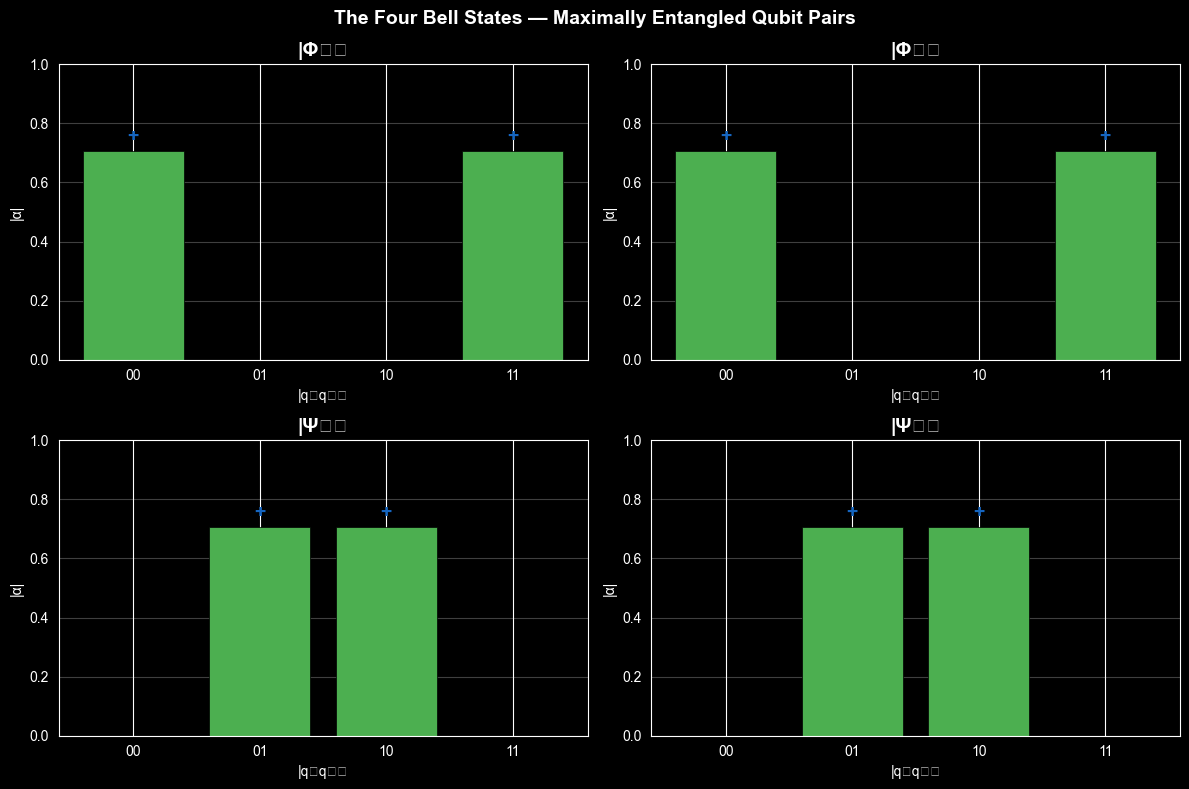

──────────────────────────────────────────────────
EPR Correlation Test: measuring |Φ+⟩
Counts: {'11': 2022, '00': 2074}
✅ Only |00⟩ and |11⟩ observed — qubits always agree (perfect correlation)!
Individual qubits appear random (50/50), but they are ALWAYS correlated.


In [9]:
# ═══ EPR Pairs / Bell States ═══════════════════════════════════════

bell_states = {}

# |\u03A6+\u27E9 = (|00\u27E9 + |11\u27E9)/\u221A2
qc_phi_p = QuantumCircuit(2)
qc_phi_p.h(0)
qc_phi_p.cx(0, 1)
bell_states['|\u03A6\u207A\u27E9'] = Statevector.from_instruction(qc_phi_p)

# |\u03A6-\u27E9 = (|00\u27E9 - |11\u27E9)/\u221A2
qc_phi_m = QuantumCircuit(2)
qc_phi_m.h(0)
qc_phi_m.cx(0, 1)
qc_phi_m.z(0)
bell_states['|\u03A6\u207B\u27E9'] = Statevector.from_instruction(qc_phi_m)

# |\u03A8+\u27E9 = (|01\u27E9 + |10\u27E9)/\u221A2
qc_psi_p = QuantumCircuit(2)
qc_psi_p.h(0)
qc_psi_p.cx(0, 1)
qc_psi_p.x(0)
bell_states['|\u03A8\u207A\u27E9'] = Statevector.from_instruction(qc_psi_p)

# |\u03A8-\u27E9 = (|01\u27E9 - |10\u27E9)/\u221A2
qc_psi_m = QuantumCircuit(2)
qc_psi_m.h(0)
qc_psi_m.cx(0, 1)
qc_psi_m.x(0)
qc_psi_m.z(0)
bell_states['|\u03A8\u207B\u27E9'] = Statevector.from_instruction(qc_psi_m)

# Visualize all four Bell states
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
labels_bell = ['00', '01', '10', '11']

for ax, (name, sv) in zip(axes.flat, bell_states.items()):
    sv_data = np.array(sv)
    mags = np.abs(sv_data)
    phases = np.angle(sv_data)
    colors_b = ['#4CAF50' if abs(sv_data[i]) > 0.01 else '#EEEEEE' for i in range(4)]
    bars = ax.bar(labels_bell, mags, color=colors_b, edgecolor='black', lw=0.5)
    for bar, m, p in zip(bars, mags, phases):
        if m > 0.01:
            sign = '+' if p > -0.01 else '-'
            ax.text(bar.get_x() + bar.get_width()/2, m + 0.03,
                    sign, ha='center', fontsize=14, fontweight='bold',
                    color='#1565C0' if sign == '+' else '#C62828')
    ax.set_ylim(0, 1.0)
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.set_xlabel('|q\u2081q\u2080\u27E9', fontsize=10)
    ax.set_ylabel('|\u03B1|', fontsize=10)
    ax.grid(axis='y', alpha=0.25)

fig.suptitle('The Four Bell States \u2014 Maximally Entangled Qubit Pairs',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Demonstrate perfect correlations via measurement
print('\u2500' * 50)
print('EPR Correlation Test: measuring |\u03A6+\u27E9')
qc_corr = QuantumCircuit(2, 2)
qc_corr.h(0)
qc_corr.cx(0, 1)
qc_corr.measure([0, 1], [0, 1])
compiled_bell = transpile(qc_corr, backend, seed_transpiler=seed)
counts_bell = backend.run(compiled_bell, shots=shots, seed_simulator=seed).result().get_counts()
print(f'Counts: {counts_bell}')
for outcome in counts_bell:
    assert outcome in ('00', '11'), f'Unexpected outcome: {outcome}'
print('\u2705 Only |00\u27E9 and |11\u27E9 observed \u2014 qubits always agree (perfect correlation)!')
print('Individual qubits appear random (50/50), but they are ALWAYS correlated.')

---
## Part V — The Unifying Perspective

### §9  Every Quantum Algorithm is an Interference Machine

We can now see the **deep unity** across all quantum algorithms. Each one follows the same physical pattern:

$$\underbrace{|0\rangle^{\otimes n}}_{\text{ground state}}
\xrightarrow{U_{\text{prepare}}}
\underbrace{\frac{1}{\sqrt{N}}\sum_x |x\rangle}_{\text{superposition}}
\xrightarrow{U_{\text{oracle}}}
\underbrace{\frac{1}{\sqrt{N}}\sum_x e^{i\varphi(x)} |x\rangle}_{\text{phase-encoded}}
\xrightarrow{U_{\text{interfere}}}
\underbrace{|\text{answer}\rangle}_{\text{constructive peak}}$$

The differences between algorithms lie in **what phase pattern the oracle writes** and **what interference transform reads it out**:

| Algorithm | Phase Pattern | Interference | Queries | Speedup |
|---|---|---|---|---|
| Bernstein-Vazirani | $(-1)^{s \cdot x}$ | $H^{\otimes n}$ | 1 | Exponential |
| Simon | $f(x) = f(x \oplus s)$ entanglement | $H^{\otimes n}$ | $O(n)$ | Exponential |
| Grover | $-1$ on marked item | Reflection about mean | $O(\sqrt{N})$ | Quadratic |
| Shor / QPE | $e^{2\pi i \cdot 2^k \varphi}$ | $\text{QFT}^{-1}$ | $O(n^2)$ | Exponential |

**The three pillars of quantum algorithmic power:**

1. **Superposition** provides exponential parallelism — probing all $2^n$ inputs simultaneously.

2. **Phase encoding** via oracles imprints problem structure into the quantum state without destroying superposition.
   This is the "write" step, enabled by **phase kickback** and **entanglement**.

3. **Interference** (the "read" step) converts invisible phase information into measurable amplitude peaks.
   Correct answers accumulate constructive interference; wrong answers cancel via destructive interference.

**EPR pairs / entanglement** serve as the connective tissue: they enable phase kickback (the oracle mechanism),
mediate correlations across registers (Simon's), and will underpin quantum error correction in future
fault-tolerant machines.

### Why Classical Computers Cannot Replicate This

Classical probabilities are **non-negative real numbers**. They can only *add*, never *cancel*.
There is no classical analogue of destructive interference.

Quantum amplitudes are **complex numbers** in a Hilbert space. Their phases allow cancellation,
and unitarity guarantees that the total probability (norm) is preserved — what is removed from wrong
answers is redistributed to correct ones.

This is why quantum speedups are not merely about "trying all answers at once" (a common misconception).
Without interference, a superposition measured randomly gives no advantage over random guessing.
**Interference is the mechanism that transforms quantum parallelism into algorithmic advantage.**

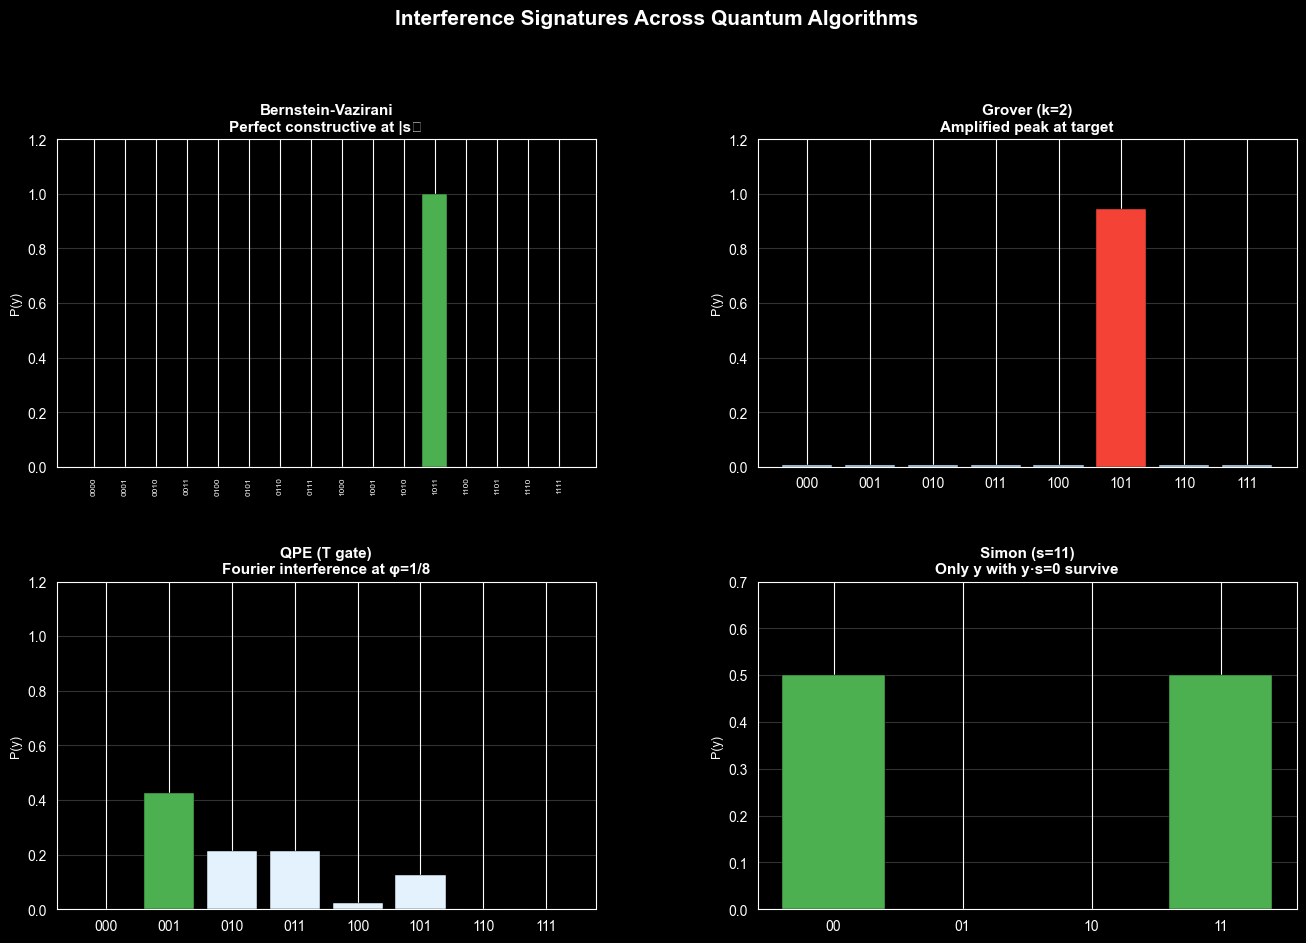

┌────────────────────────────────────────────────────────────┐
│ Every panel shows the SAME physics:                       │
│ Constructive interference at the answer,                  │
│ destructive interference everywhere else.                 │
│ The difference is HOW the phases are written and read.    │
└────────────────────────────────────────────────────────────┘


In [10]:
# ═══ Algorithm Comparison: Interference Signatures ═════════════════

fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)

# 1. Bernstein-Vazirani: perfect spike at |s\u27E9
ax1 = fig.add_subplot(gs[0, 0])
n_bv = 4
bv_probs = np.zeros(2**n_bv)
bv_probs[int(secret, 2)] = 1.0
labels_bv = [format(i, f'0{n_bv}b') for i in range(2**n_bv)]
colors_bv = ['#4CAF50' if p > 0.5 else '#E3F2FD' for p in bv_probs]
ax1.bar(labels_bv, bv_probs, color=colors_bv, edgecolor='black', lw=0.3)
ax1.set_title('Bernstein-Vazirani\nPerfect constructive at |s\u27E9', fontsize=11, fontweight='bold')
ax1.set_ylabel('P(y)', fontsize=9)
ax1.set_ylim(0, 1.2)
ax1.tick_params(axis='x', rotation=90, labelsize=6)
ax1.grid(axis='y', alpha=0.2)

# 2. Grover: amplified peak at target after optimal iterations
ax2 = fig.add_subplot(gs[0, 1])
grover_amps = amp_history[2][1]  # After 2 iterations (optimal)
grover_probs = grover_amps**2
labels_g = [format(i, f'0{n_grover}b') for i in range(N_grover)]
colors_g = ['#F44336' if i == target else '#BBDEFB' for i in range(N_grover)]
ax2.bar(labels_g, grover_probs, color=colors_g, edgecolor='black', lw=0.3)
ax2.set_title('Grover (k=2)\nAmplified peak at target', fontsize=11, fontweight='bold')
ax2.set_ylabel('P(y)', fontsize=9)
ax2.set_ylim(0, 1.2)
ax2.grid(axis='y', alpha=0.2)

# 3. QPE: sharp peak at \u03C6 encoding
ax3 = fig.add_subplot(gs[1, 0])
colors_q = ['#4CAF50' if i == 1 else '#E3F2FD' for i in range(2**t)]
ax3.bar(labels_qpe, probs_counting, color=colors_q, edgecolor='black', lw=0.3)
ax3.set_title('QPE (T gate)\nFourier interference at \u03C6=1/8', fontsize=11, fontweight='bold')
ax3.set_ylabel('P(y)', fontsize=9)
ax3.set_ylim(0, 1.2)
ax3.grid(axis='y', alpha=0.2)

# 4. Simon: interference filters orthogonal subspace
ax4 = fig.add_subplot(gs[1, 1])
colors_si = ['#4CAF50' if p > 0.01 else '#FFCDD2' for p in probs_input]
ax4.bar(labels_s, probs_input, color=colors_si, edgecolor='black', lw=0.3)
ax4.set_title('Simon (s=11)\nOnly y with y\u00B7s=0 survive', fontsize=11, fontweight='bold')
ax4.set_ylabel('P(y)', fontsize=9)
ax4.set_ylim(0, 0.7)
ax4.grid(axis='y', alpha=0.2)

fig.suptitle('Interference Signatures Across Quantum Algorithms',
             fontsize=15, fontweight='bold', y=1.01)
plt.show()

print('\u250C' + '\u2500'*60 + '\u2510')
print('\u2502 Every panel shows the SAME physics:                       \u2502')
print('\u2502 Constructive interference at the answer,                  \u2502')
print('\u2502 destructive interference everywhere else.                 \u2502')
print('\u2502 The difference is HOW the phases are written and read.    \u2502')
print('\u2514' + '\u2500'*60 + '\u2518')

---
## Key Takeaways

| Concept | Insight |
|---|---|
| **Complex amplitudes** | Quantum states carry both magnitude and phase; probability ($|\alpha|^2$) discards phase, but interference uses it |
| **Interference term** | $|\alpha_1 + \alpha_2|^2 = |\alpha_1|^2 + |\alpha_2|^2 + 2\,\text{Re}(\alpha_1^*\alpha_2)$ — the cross-term is the quantum advantage |
| **Phase kickback** | Oracles encode problem information into phases via eigenvalue kickback; the ancilla is a catalyst |
| **Algorithm blueprint** | Prepare superposition → oracle writes phases → interference reads phases → measure |
| **Bernstein-Vazirani** | $H^{\otimes n}$ after phase oracle produces perfect constructive interference at $|s\rangle$ |
| **Grover** | Repeated oracle + diffusion rotates the state toward the target in 2D amplitude space |
| **QPE / Shor** | Controlled unitaries encode phase into counting qubits; inverse QFT creates constructive peak |
| **Simon** | Entanglement + Hadamard interference filters outcomes to subspace orthogonal to hidden $s$ |
| **EPR / Entanglement** | Enables non-local phase correlations; mediates kickback and inter-register interference |
| **Classical impossibility** | Classical probabilities are non-negative reals — they cannot cancel, so no classical analogue of destructive interference exists |

> **The art of quantum algorithm design is the art of choosing the right phase pattern**
> **(oracle) and the right interference transform to read it out.**